In [1]:
from utils import get_match_df, analyze_strategies, get_best_leagues, get_best_strategies, compare_strategies

df = get_match_df()

df.tail()

/home/maicolnicolini/code/bet-master-analytics/src/strategies/utils.py:132: FutureWarning: Logical ops (and, or, xor) between Pandas objects and dtype-less sequences (e.g. list, tuple) are deprecated and will raise in a future version. Wrap the object in a Series, Index, or np.array before operating instead.
  df_final = df_final[other_strategies_mask | dnb_mask]


,date,time,league,home_team,away_team,goal_home,goal_away,strategy,result,return,week
match_id,,,,,,,,,,,
d19441414,2026-03-28,21:00,La Liga 2,Albacete,Castellón,1,1,BTTS,True,0.5,12
d19456259,2026-03-28,18:30,Primera RFEF Gruppo 1,Arenas de Getxo,Real Avilés,3,2,Over 1.5 (M2-X),True,0.5,12
d19637305,2026-03-29,21:00,Argentina B,Deportivo Madryn,San Martín de Tucumán,1,1,Over 1.5 (M2-X),True,0.5,12
d19441415,2026-03-29,21:00,La Liga 2,Almería,Real Sociedad II,5,1,Goal Home HT,True,0.5,12
d19503510,2026-03-29,17:30,Serie C: Girone A,Cittadella,Lecco,2,1,DNB 1,True,0.4,12


## Approccio 1: Scommetto tutti i mercati e tutti i campionati

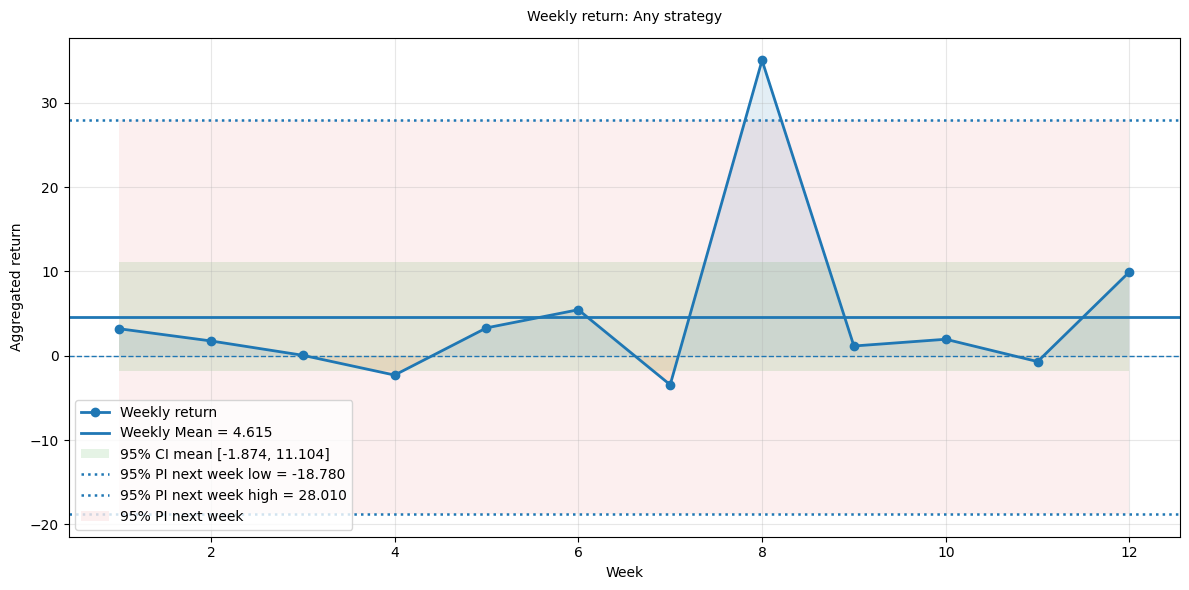

In [2]:
weekly_return, stats = analyze_strategies(df, print_pi=True)

In [3]:
weekly_return

week
1      3.20
2      1.75
3      0.05
4     -2.30
5      3.30
6      5.45
7     -3.45
8     35.03
9      1.15
10     1.95
11    -0.70
12     9.95
Name: return, dtype: float64

95% PI è la probabilità che il ritorno della prossima settimana sia compreso fra PI low e PI high
### Note:
1. Ritorno medio è positivo ma a estremo inferiore CI negativo -> non è detto che il vero valor medio del ritorno settimanale è > 0
2. 95% PI estremamente variabile

## Approccio 2: scommetto i mercati che si comportano meglio su tutti i campionati

In [13]:
strategy_df = get_best_strategies(df)
strategy_df

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
BTTS,2.76,9.25,5.25,8.55,63,0.74
Over 1.5 (M2-X),1.06,2.13,7.83,6.77,94,0.79
Goal HT,0.54,1.84,5.58,3.93,67,0.82
DNB 1,0.30,2.28,7.50,4.31,90,0.72
Win x2 HT,0.30,1.61,2.00,1.58,24,0.64
Multigoal 1-2 Home,0.28,1.27,1.00,1.15,12,0.79
Goal Home HT,-0.35,1.33,1.67,1.11,20,0.63


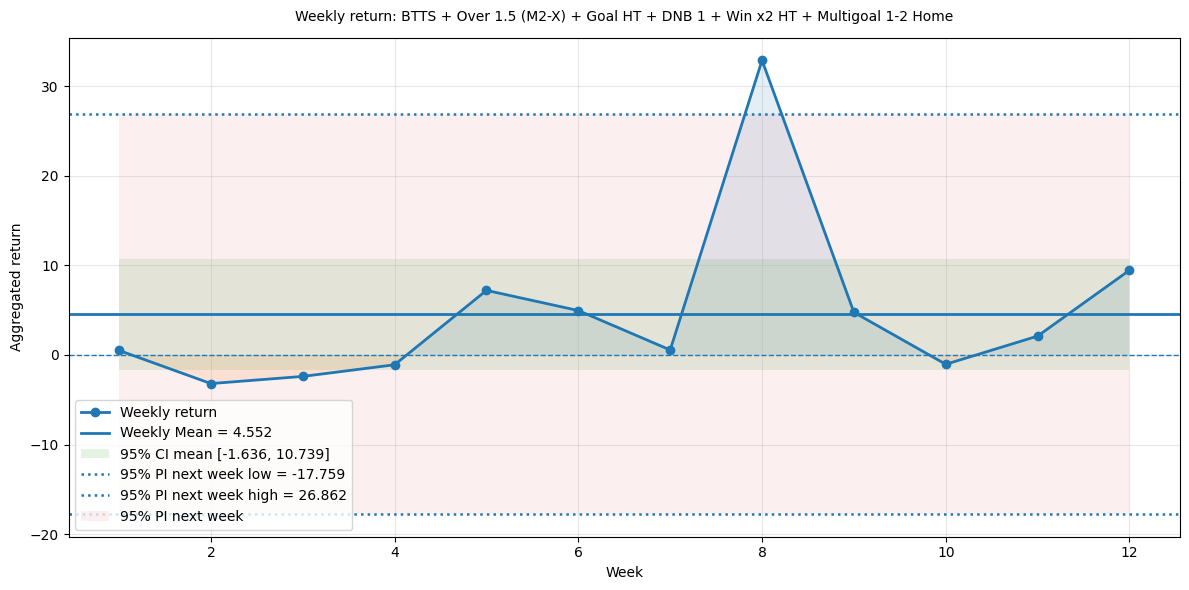

In [5]:
# Tolgo mercati con ritorno medio settimanale negativo e analizzo le strategie
best_strategies = strategy_df[strategy_df["weekly_mean_return"] > 0].index.to_list()
weekly_return, stats = analyze_strategies(df, strategies=best_strategies, print_pi=True)

In [6]:
weekly_return

week
1     0.50
2    -3.20
3    -2.40
4    -1.10
5     7.20
6     4.95
7     0.55
8    32.87
9     4.75
10   -1.05
11    2.10
12    9.45
Name: return, dtype: float64

### Note:
- Valor medio leggermente più alto ma meno confidente (CI mean)
- Intervallo PI maggiore -> più volatile
- Andando a vedere sopra, BTTS è quello che porta più ritorno ma è quello più volatile (ha performato particolarmente bene in week 7), provo a toglierlo

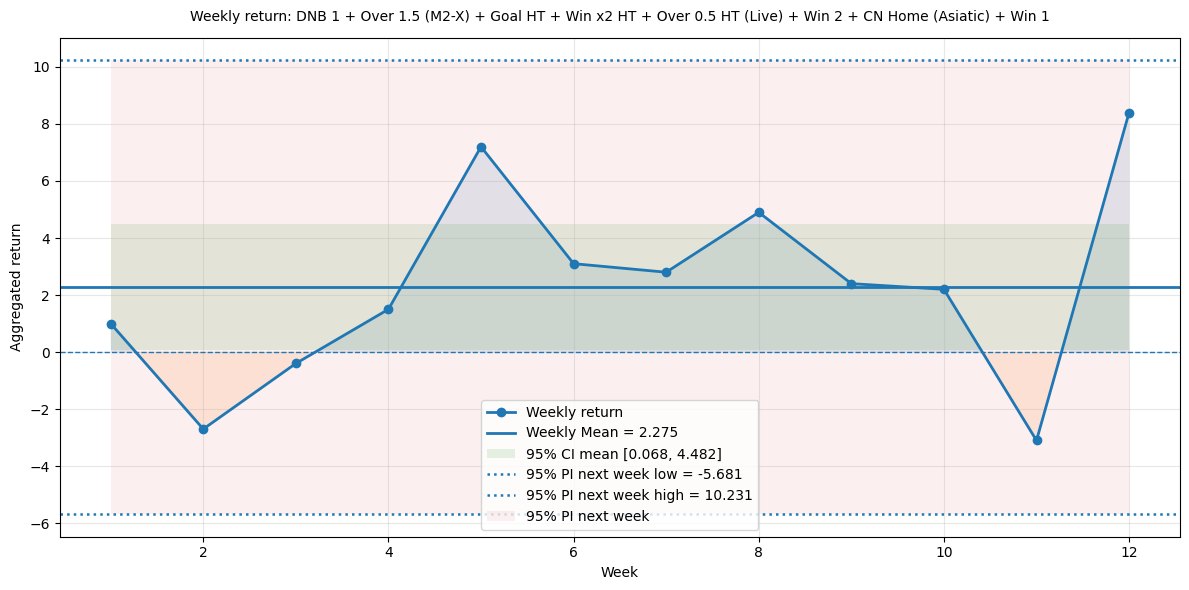

In [7]:
weekly_return, stats = analyze_strategies(df, strategies=['DNB 1', 'Over 1.5 (M2-X)', 'Goal HT', 'Win x2 HT', 'Over 0.5 HT (Live)', 'Win 2', 'CN Home (Asiatic)', 'Win 1'], print_pi=True)

In [8]:
weekly_return

week
1     1.00
2    -2.70
3    -0.40
4     1.50
5     7.20
6     3.10
7     2.80
8     4.90
9     2.40
10    2.20
11   -3.10
12    8.40
Name: return, dtype: float64

### Note:
- ritorno medio minore ma CI low > 0 -> al 95% il ritorno medio settimanale è positivo
- PI molto meno variabile

## Approccio 3: scommetto solo sui campionati migliori

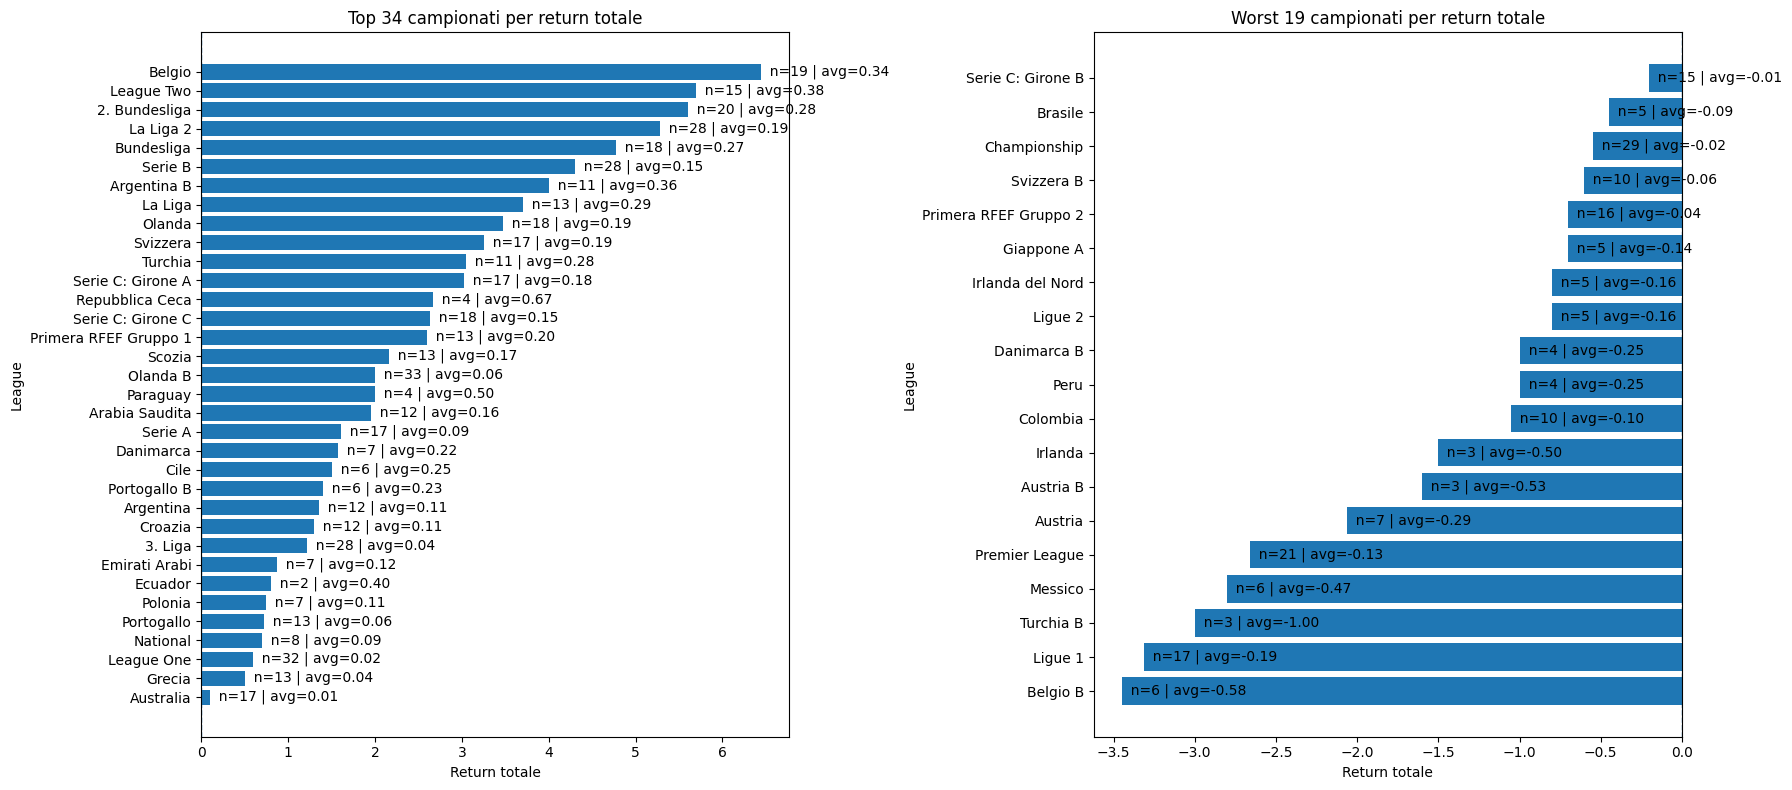

In [14]:
best_leagues = get_best_leagues(df)

In [15]:
threshold = best_leagues["n_matches"].quantile(q=0.1)
print(f"Threshold: {threshold}")
league_list = list(best_leagues[best_leagues["n_matches"] > threshold].index)

Threshold: 6.0


In [16]:
# Vedo quali sono le migliori scommesse per i campionati con ritorno positivo (considero solo campionati grafico a sx)
get_best_strategies(df, leagues=league_list)

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
BTTS,2.35,7.22,4.25,6.67,51,0.79
Over 1.5 (M2-X),0.94,1.24,4.92,4.25,59,0.82
Win x2 HT,0.82,1.19,1.33,1.18,16,0.87
Goal HT,0.75,1.39,3.75,2.24,45,0.86
DNB 1,0.66,2.07,5.42,2.98,65,0.80
Multigoal 1-2 Home,-0.07,0.85,0.42,0.49,5,0.60
Goal Home HT,-0.38,1.36,1.25,1.16,15,0.62


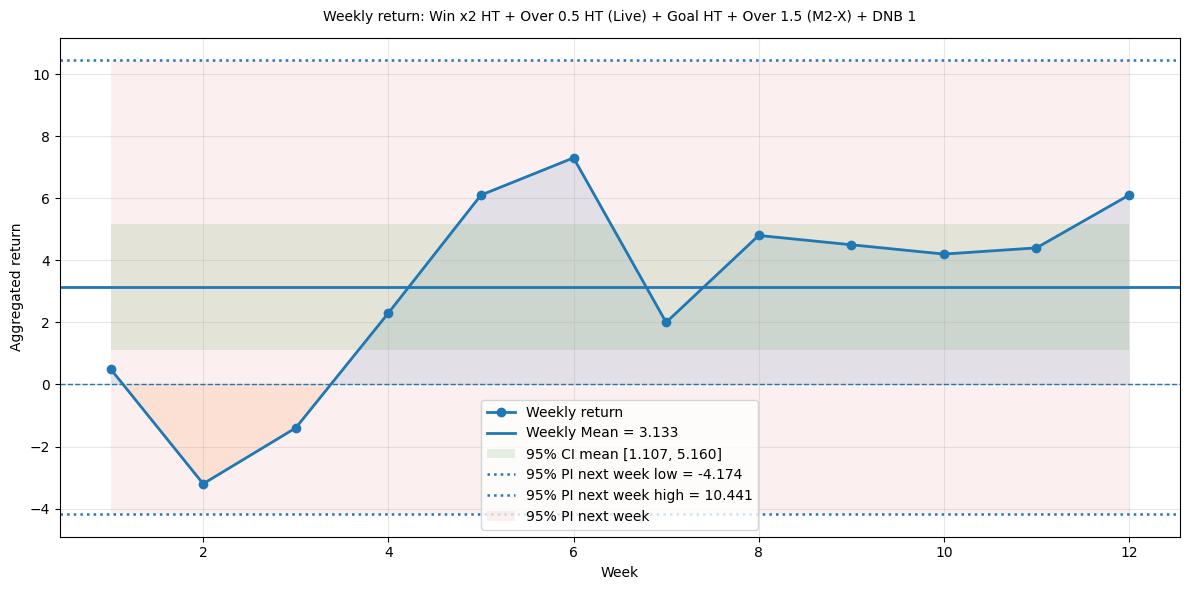

In [17]:
# Prendo le strategie migliori togliendo CN Home perchè ha ritorno negativo e BTTS per alta volatilità
best_strategies = ['Win x2 HT', 'Over 0.5 HT (Live)', 'Goal HT', 'Over 1.5 (M2-X)', 'DNB 1']

weekly_return, stats_1 = analyze_strategies(df, strategies=best_strategies, leagues=league_list, print_pi=True)

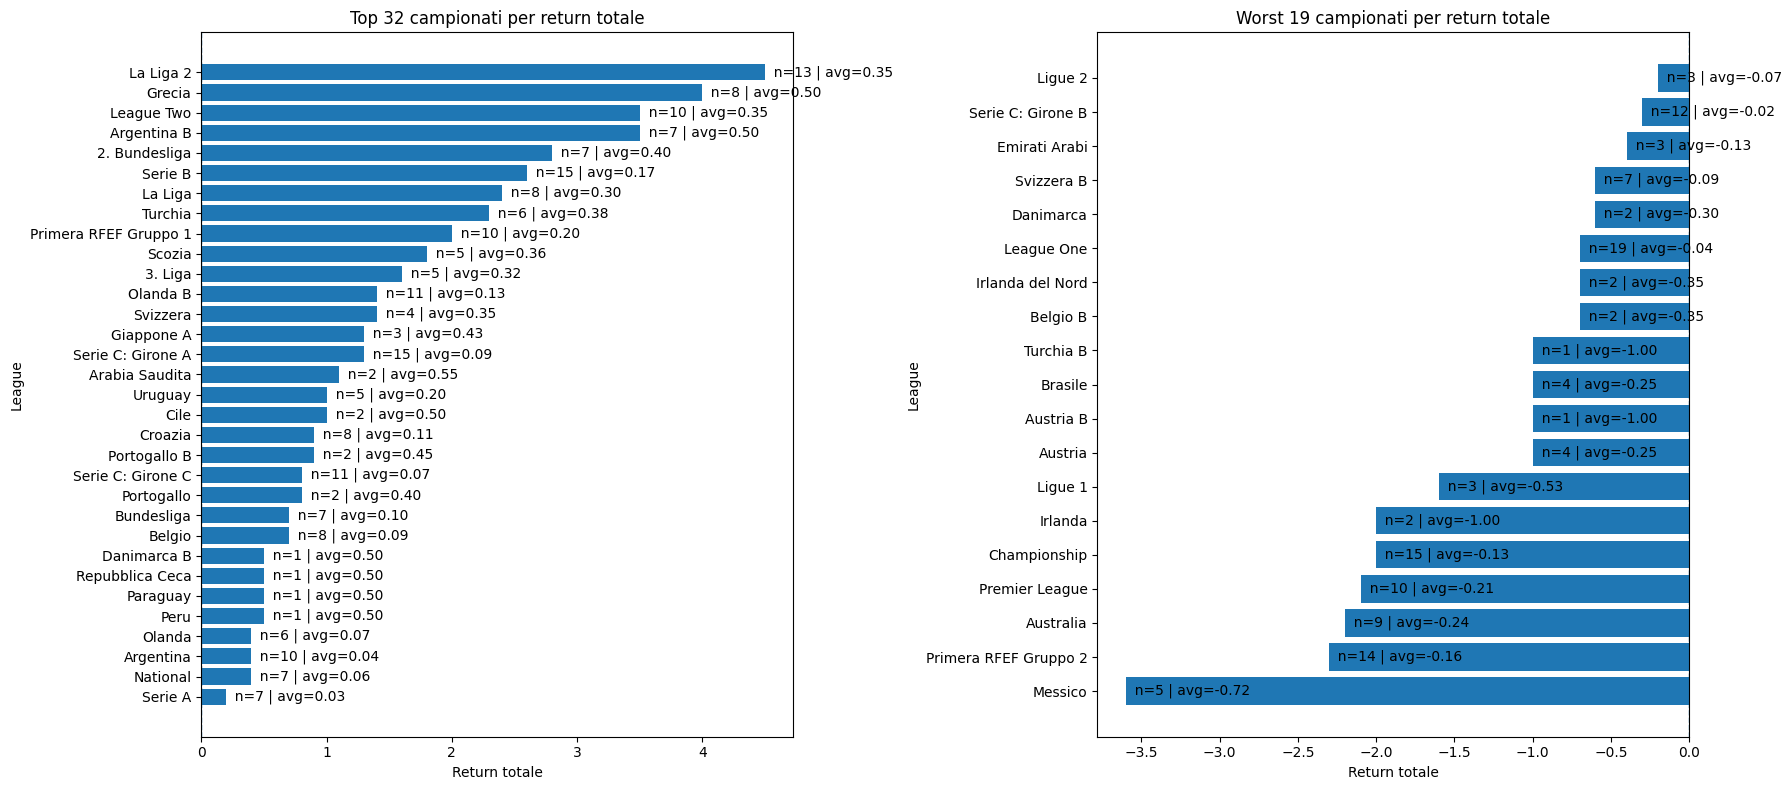

Threshold: 1.1


In [18]:
# Find the best leageus for the best strategies 
best_leagues = get_best_leagues(df, strategies=best_strategies)
threshold = best_leagues["n_matches"].quantile(q=0.1)
league_list = list(best_leagues[best_leagues["n_matches"] > threshold].index)

print(f"Threshold: {threshold}")

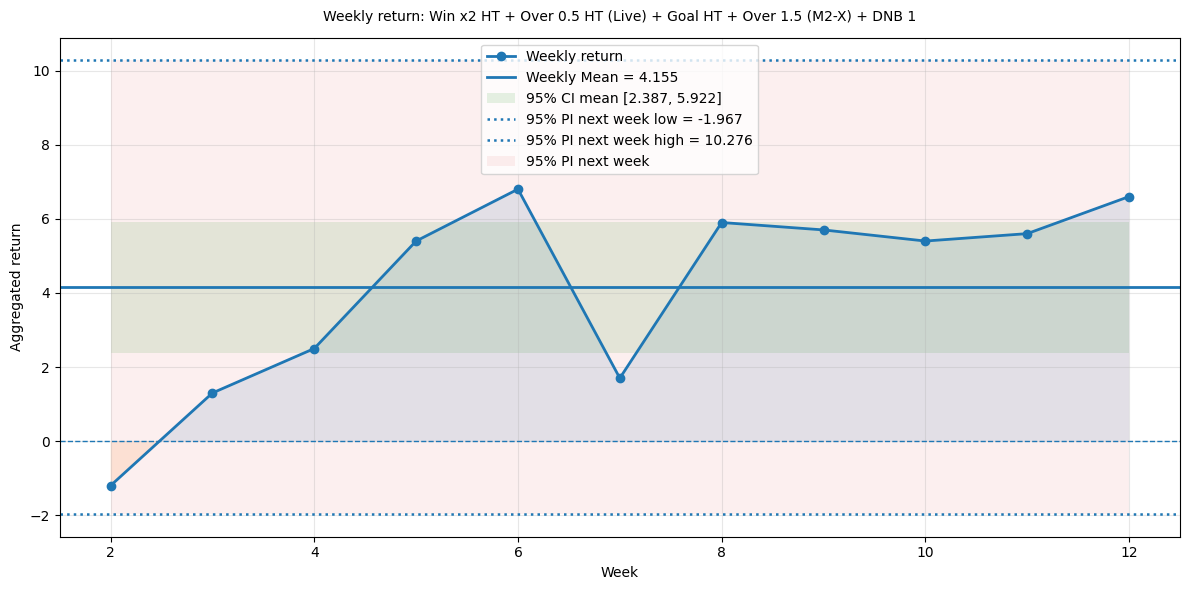

In [19]:
weekly_return, stats_2 = analyze_strategies(df, strategies=best_strategies, leagues=league_list, print_pi=True)

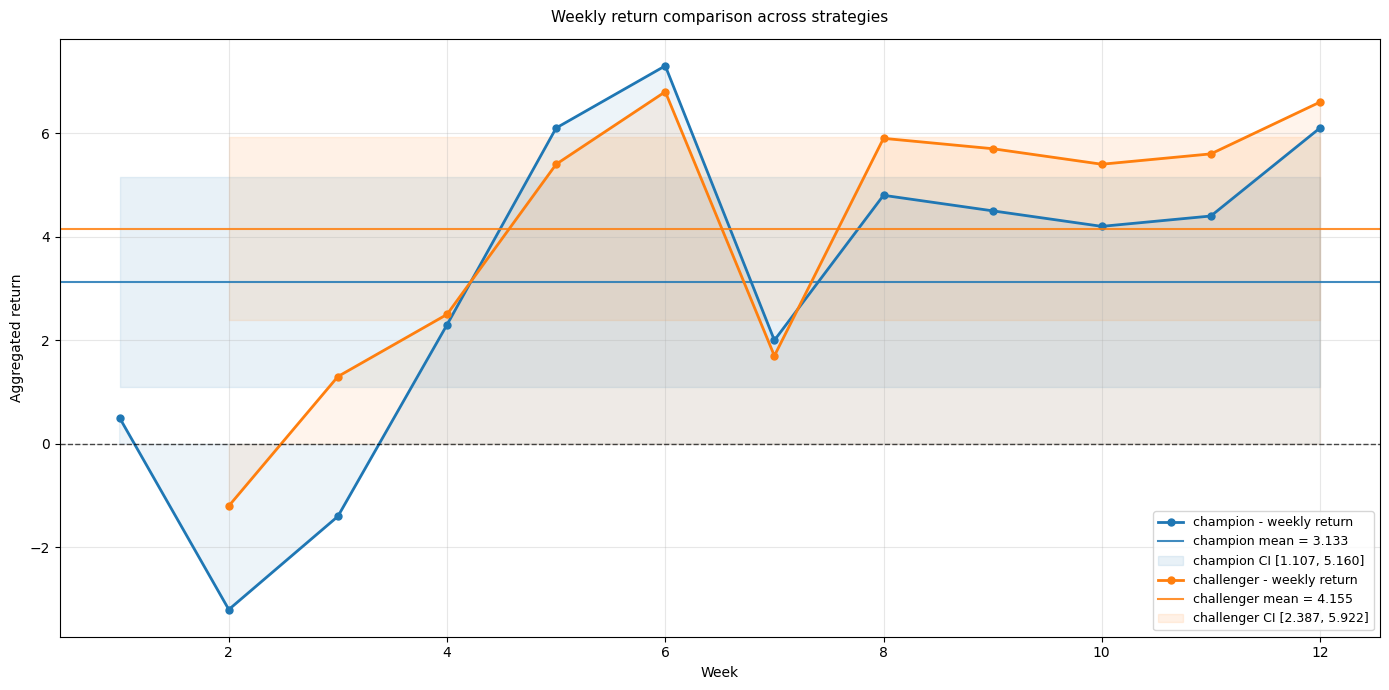

In [20]:
strategies_to_compare = {"champion": stats_1, "challenger": stats_2}

aggregated_data, summary_df = compare_strategies(
    df=df,
    strategies=strategies_to_compare,
    show_ci=True,
    show_pi=False
)

In [27]:
weekly_return

week
2    -1.20
3     1.30
4     2.50
5     5.40
6     6.80
7     1.70
8     5.90
9     5.70
10    5.40
11    5.60
12    6.60
Name: return, dtype: float64

In [21]:
summary_df

,label,strategy,leagues,n_weeks,expected_bets_per_week,mean_weekly_agg_return,std_weekly_agg_return,sem,ci_low,ci_high,pi_low,pi_high
0,champion,"[Win x2 HT, Over 0.5 HT (Live), Goal HT, Over ...","[Belgio, League Two, 2. Bundesliga, La Liga 2,...",12,18,3.13,3.19,0.92,1.11,5.16,-4.17,10.44
1,challenger,"[Win x2 HT, Over 0.5 HT (Live), Goal HT, Over ...","[La Liga 2, Grecia, Argentina B, League Two, 2...",11,17,4.15,2.63,0.79,2.39,5.92,-1.97,10.28


### Note:
- Ritorno medio più alto del precedente ma ancora minore del primo
- Confidenza molto più alta sia del primo che del secondo (CI low 1.5 vuol dire che il valor medio sul lungo periodo è almeno 1.53 al 95% di confidenza)
- Variabilità sulla settimana (PI) maggiore di prima ma più spostato verso l'alto